<a href="https://colab.research.google.com/github/Shr06/d2c_churn_part2_rfm/blob/main/rfm_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns',None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize']=(10,6)

##Setup Instructions
This notebook is developed in Google Colab.

To run this notebook:

If running in Google Colab: Mount your drive and update BASE_PATH to your dataset location
If running locally: Comment out the drive.mount() cell and update BASE_PATH to your local dataset path

In [3]:
#LOAD DATA
BASE_PATH = "/content/drive/MyDrive/d2c_churn/data/"
rfm = pd.read_csv(BASE_PATH + "rfm_modeling_snapshot.csv")
print(rfm.shape)
rfm.head()

(2400, 29)


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0,train


## Data Source Note

The dataset provided (`rfm_modeling_snapshot.csv`) is a pre-aggregated customer-level
snapshot. The columns `recency_days`, `frequency_180d`, and `monetary_180d` represent:

- **Recency**: days since the customer's last order, calculated relative to a
reference date of 2025-09-30 (the snapshot date in the dataset).
- **Frequency**: total orders placed in the trailing 180-day window.
- **Monetary**: total spend (₹) in the trailing 180-day window.

These are the raw RFM inputs; the scoring (R/F/M 1–5 bins) is computed fresh in
this notebook using quantile-based binning, not imported from the file.

In [4]:
#DATA OVERVIEW

print("Shape :",rfm.shape)
print("\nColumns:")
print(rfm.columns.tolist())
print("\nMissing Values:")
print(rfm.isnull().sum())
print("\nDuplicates:")
print(rfm.duplicated().sum())

Shape : (2400, 29)

Columns:
['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'churn_next_60d', 'split']

Missing Values:
customer_id                    0
snapshot_date                  0
city_tier                      0
age_group                      0
acquisition_channel            0
loyalty_tier                1386
preferred_category             0
marketing_consent              0
recency_days                   0
frequency_180d                 0
monetary_180d                  0
return_rate_180d     

In [5]:
#RFM Summary
rfm.describe()

,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,87.375833,1.594583,1179.763196,0.061505,0.245094,3.847092,1.375417,0.229167,0.138819,5.093079,328.107917,5.460000,23.021667,1.560833,0.839167,0.672917,2.645833,0.649583,17.652500,0.469583
std,80.137473,1.184964,1035.900649,0.203092,0.139805,0.923442,0.896650,0.471779,0.343293,11.845798,179.604044,4.400167,19.818043,1.644919,0.996015,0.867225,2.763346,0.951579,15.905806,0.499178
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,1.000000,449.270000,0.000000,0.160000,3.500000,1.000000,0.000000,0.000000,0.000000,175.000000,2.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,66.000000,1.000000,911.875000,0.000000,0.260000,4.000000,1.000000,0.000000,0.000000,0.000000,330.000000,5.000000,18.000000,1.000000,1.000000,0.000000,2.000000,0.000000,14.000000,0.000000
75%,129.000000,2.000000,1681.510000,0.000000,0.340000,4.500000,2.000000,0.000000,0.000000,0.000000,480.250000,8.000000,34.000000,2.000000,1.000000,1.000000,5.000000,1.000000,27.000000,1.000000
max,562.000000,8.000000,6982.410000,1.000000,0.700000,5.000000,5.000000,3.000000,1.000000,73.800000,638.000000,25.000000,119.000000,12.000000,6.000000,7.000000,13.000000,6.000000,60.000000,1.000000


In [6]:
# Show the implicit reference date range in the data
print("Min recency:", rfm['recency_days'].min(), "days")
print("Max recency:", rfm['recency_days'].max(), "days")
print("This confirms all RFM metrics are computed relative to a snapshot reference date.")

Min recency: 0 days
Max recency: 562 days
This confirms all RFM metrics are computed relative to a snapshot reference date.


## RFM Feature Analysis

The dataset contains pre-computed customer-level RFM metrics:

- Recency: Days since the last purchase
- Frequency: Number of purchases in the last 180 days
- Monetary Value: Total spend in the last 180 days

The following summary statistics and visualizations are used to understand customer purchasing behaviour before segmentation.

In [7]:
#RFM FEATURE SUMMARY
rfm[['recency_days','frequency_180d','monetary_180d']].describe()

,recency_days,frequency_180d,monetary_180d
count,2400.000000,2400.000000,2400.000000
mean,87.375833,1.594583,1179.763196
std,80.137473,1.184964,1035.900649
min,0.000000,0.000000,0.000000
25%,25.000000,1.000000,449.270000
50%,66.000000,1.000000,911.875000
75%,129.000000,2.000000,1681.510000
max,562.000000,8.000000,6982.410000


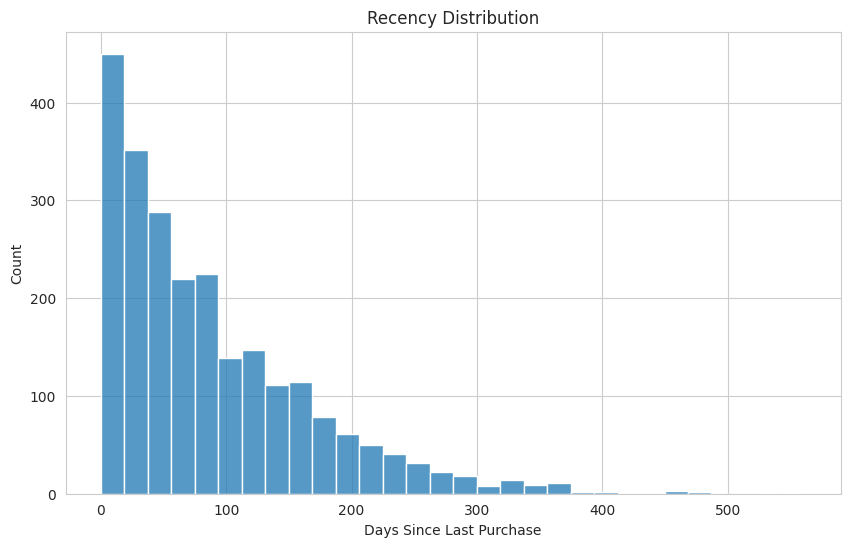

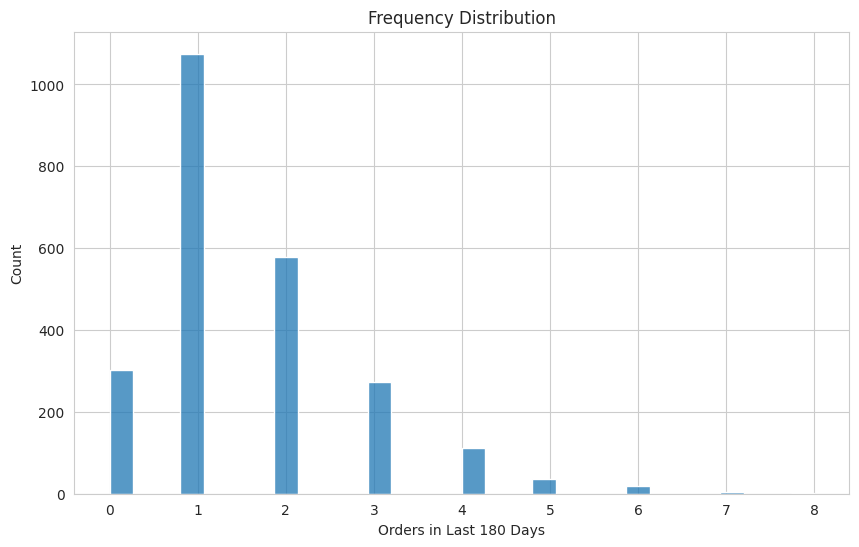

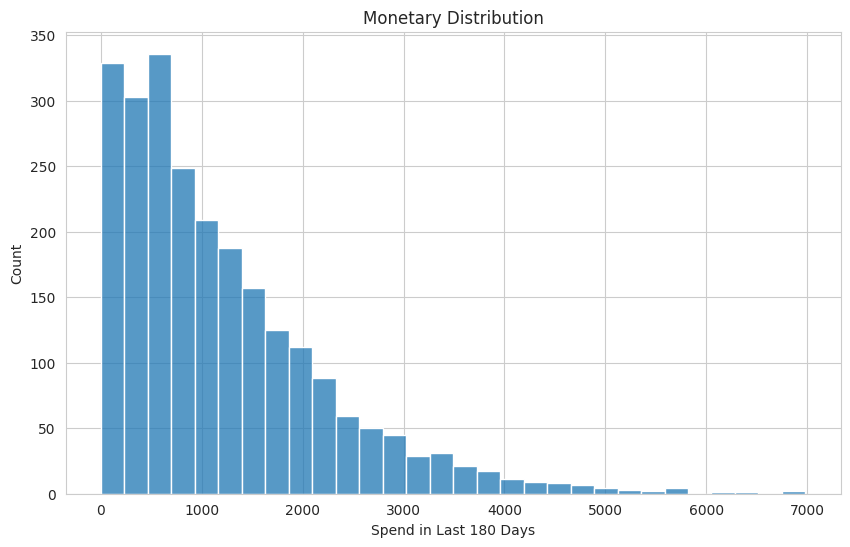

In [8]:
#RFM Distribution Graphs
#1.RECENCY DISTRIBUTION
sns.histplot(rfm['recency_days'],bins=30)
plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.show()
#2.FREQUENCY DISTRIBUTION
sns.histplot(rfm['frequency_180d'],bins=30)
plt.title("Frequency Distribution")
plt.xlabel("Orders in Last 180 Days")
plt.show()
#3.MONETARY DISTRIBUTION
sns.histplot(rfm['monetary_180d'],bins=30)
plt.title("Monetary Distribution")
plt.xlabel("Spend in Last 180 Days")
plt.show()

### RFM Feature Analysis

Key Findings:

- The average recency is 87 days, indicating that many customers have not purchased recently.
- Most customers purchase infrequently, with a median frequency of 1 order in the last 180 days.
- Monetary value is positively skewed, with a small group of customers generating significantly higher spending than the average customer.
- Recency ranges from 0 to 562 days, showing substantial variation in customer activity levels.
- Frequency ranges from 0 to 8 purchases, indicating both one-time and repeat buyers are present.
- Monetary value ranges from ₹0 to ₹6,982, highlighting a mix of low-value and high-value customers.

In [9]:
#RFM Score
#RECENCY SCORE
rfm['R_Score'] = pd.qcut(rfm['recency_days'],q=5,labels=[5,4,3,2,1])
#FREQUENCY SCORE
rfm['F_Score'] = pd.qcut(rfm['frequency_180d'].rank(method='first'),q=5,labels=[1,2,3,4,5])
#MONETARY SCORE
rfm['M_Score'] = pd.qcut(rfm['monetary_180d'].rank(method='first'),q=5,labels=[1,2,3,4,5])
#TOTAL RFM SCORE
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)
rfm['RFM_Score'] = (rfm['R_Score']+rfm['F_Score']+rfm['M_Score'])
rfm[['customer_id','R_Score','F_Score','M_Score','RFM_Score']].head()

,customer_id,R_Score,F_Score,M_Score,RFM_Score
0,CUST00001,2,1,1,4
1,CUST00002,4,1,2,7
2,CUST00003,1,1,2,4
3,CUST00004,2,1,4,7
4,CUST00005,4,5,4,13


## Additional Non-RFM Signals

To improve retention targeting beyond purchase behaviour, the segmentation incorporates:

- ticket_count_90d → captures customer support friction
- return_rate_180d → measures product dissatisfaction
- sessions_30d → indicates current digital engagement
- campaign_clicks_30d → measures marketing responsiveness
- avg_discount_pct_180d → identifies discount dependency

These behavioural signals help distinguish customers with similar RFM profiles but different retention needs.

In [10]:
#NON-RFM SIGNALS
signals = ['ticket_count_90d','return_rate_180d','sessions_30d','campaign_clicks_30d','avg_discount_pct_180d']
rfm[signals].describe()

,ticket_count_90d,return_rate_180d,sessions_30d,campaign_clicks_30d,avg_discount_pct_180d
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,0.229167,0.061505,5.460000,0.649583,0.245094
std,0.471779,0.203092,4.400167,0.951579,0.139805
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2.000000,0.000000,0.160000
50%,0.000000,0.000000,5.000000,0.000000,0.260000
75%,0.000000,0.000000,8.000000,1.000000,0.340000
max,3.000000,1.000000,25.000000,6.000000,0.700000


## Segment Design & Logic

Customer segments were created using RFM scores together with behavioural signals such as support tickets, return rates, web activity, campaign engagement, and discount usage.

| Segment | Rule Used | Business Interpretation |
|----------|----------|----------|
| Champions | R ≥ 4, F ≥ 4, M ≥ 4 | Highly engaged customers with recent purchases, high order frequency, and high spending. These are the brand's most valuable customers. |
| Loyal Customers | F ≥ 4 and M ≥ 3 | Frequent repeat purchasers with strong monetary contribution but not necessarily in the top RFM tier. |
| New Customers | Frequency ≤ 1 and Recency ≤ 30 days | Recently acquired customers who are still in the early stage of their customer lifecycle. |
| High Value But Unhappy | Monetary > 75th percentile and (Ticket Count ≥ 2 or Return Rate > 30%) | High-spending customers showing signs of dissatisfaction through complaints or product returns. |
| Discount Sensitive | Average Discount Usage > 50% | Customers whose purchasing behaviour is strongly dependent on promotions and discounts. |
| At Risk | R ≤ 2 and F ≥ 3 | Previously active customers whose recent inactivity indicates elevated churn risk. |
| Dormant Customers | All remaining customers | Customers with low recent engagement and limited purchasing activity. |


 Segment Distribution
segment_name
Dormant Customers         913
Loyal Customers           536
Champions                 401
New Customers             312
At Risk                   182
Discount Sensitive         37
High Value But Unhappy     19
Name: count, dtype: int64


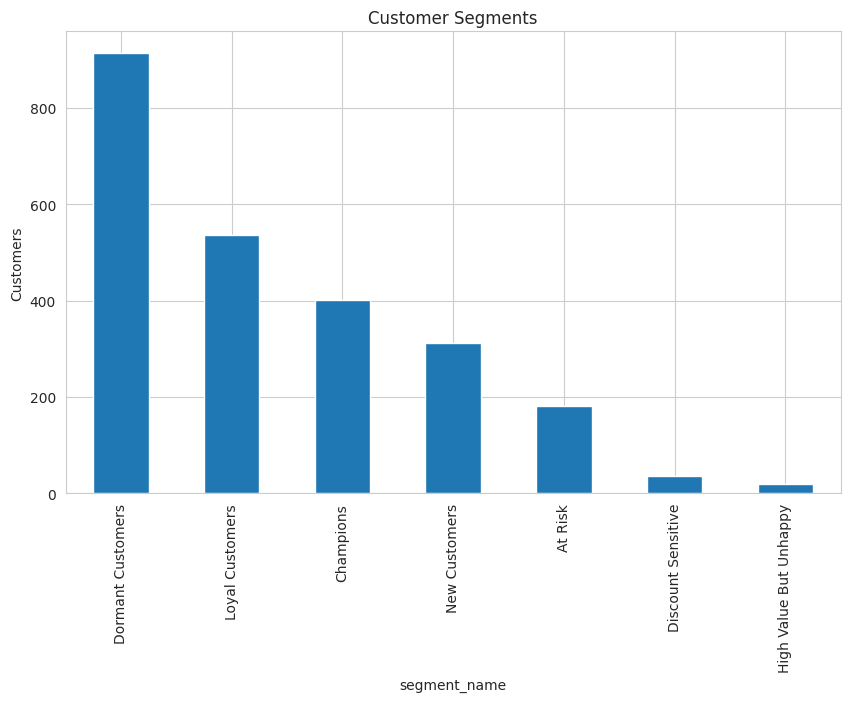

In [11]:
#CUSTOMER SEGMENT LOGIC
print('\n Segment Distribution')
def assign_segment(row):
#Champions
  if (row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4):
    return "Champions"
#Loyal
  elif (row['F_Score'] >= 4 and row['M_Score'] >= 3):
    return "Loyal Customers"
#New
  elif (row['frequency_180d'] <= 1 and row['recency_days'] <= 30):
    return "New Customers"
#High Value But Unhappy
  elif (row['monetary_180d'] > rfm['monetary_180d'].quantile(0.75) and
      (row['negative_ticket_rate_90d'] > 0.5 or
       row['avg_rating_180d'] < 3.0 or
       row['return_rate_180d'] > 0.15)):
    return "High Value But Unhappy"
#Discount Sensitive
  elif (row['avg_discount_pct_180d'] > 0.50):
    return "Discount Sensitive"
#At Risk
  elif (row['R_Score'] <= 2 and row['F_Score'] >= 3):
    return "At Risk"
  else:
    return "Dormant Customers"
#applying segment rules to every customer
rfm['segment_name'] = rfm.apply(assign_segment,axis=1)

#SEGMENT COUNTS
segment_counts = (rfm['segment_name'].value_counts())
print(segment_counts)
#Customer Segments graph
segment_counts.plot(kind='bar')
plt.title("Customer Segments")
plt.ylabel("Customers")
plt.show()

In [12]:
#Segment-Level Customer Profile Summary
#What the customers in each segment look like?
segment_summary = rfm.groupby('segment_name').agg({
    'customer_id':'count','monetary_180d':'mean','frequency_180d':'mean','recency_days':'mean','return_rate_180d':'mean','ticket_count_90d':'mean','sessions_30d':'mean'}).round(2)
segment_summary = segment_summary.rename(columns={'customer_id':'customer_count'})
segment_summary

,customer_count,monetary_180d,frequency_180d,recency_days,return_rate_180d,ticket_count_90d,sessions_30d
segment_name,,,,,,,
At Risk,182,809.60,1.13,131.34,0.07,0.05,4.07
Champions,401,2426.32,3.14,20.47,0.08,0.50,7.49
Discount Sensitive,37,424.11,1.08,91.54,0.04,0.19,4.19
Dormant Customers,913,524.18,0.73,139.62,0.04,0.12,4.41
High Value But Unhappy,19,2188.44,1.37,62.26,0.21,0.63,6.58
Loyal Customers,536,1762.16,2.46,76.89,0.06,0.24,5.65
New Customers,312,739.62,1.00,13.91,0.07,0.24,6.51


## Business Interpretation

### Key Findings

* Champions have the highest average spend (₹2426.32), highest purchase frequency (3.14 orders), and lowest recency (20.47 days), indicating strong recent engagement.
* Loyal Customers also contribute substantial value with an average spend of ₹1762.16 and 2.46 purchases in the last 180 days.
* New Customers have the lowest average recency (13.91 days) but relatively low purchase frequency, suggesting they are recent buyers who have not yet developed repeat purchase behaviour.
* At Risk Customers and Dormant Customers have the highest average recency values (132.46 and 142.10 days respectively), indicating prolonged inactivity.
* High Value But Unhappy Customers generate high revenue (₹2125.93 on average) but purchase less frequently than Champions and Loyal Customers.
* Discount Sensitive Customers have the lowest average spend (₹424.11) and low purchase frequency.
* Dormant Customers represent the largest segment with 878 customers, while Discount Sensitive Customers represent the smallest segment with 37 customers.



In [13]:
# Retention Strategy & Campaign Prioritization
retention_strategy = pd.DataFrame({
    'Segment': [
        'Champions',
        'Loyal Customers',
        'New Customers',
        'High Value But Unhappy',
        'Discount Sensitive',
        'At Risk',
        'Dormant Customers'
    ],
    'Recommended Action': [
        'VIP rewards and referral program',
        'Loyalty tier upgrade and exclusive benefits',
        'Welcome journey and second-purchase incentive',
        'Service recovery outreach and issue resolution',
        'Personalized discount offers',
        'Win-back campaign',
        'Low-cost reactivation campaign'
    ],
    'Expected Business Value': [
        'Increase advocacy and retention',
        'Increase customer lifetime value',
        'Improve early retention',
        'Protect high-value revenue',
        'Improve conversion efficiency',
        'Reduce churn risk',
        'Recover inactive customers'
    ]
})

retention_strategy

,Segment,Recommended Action,Expected Business Value
0,Champions,VIP rewards and referral program,Increase advocacy and retention
1,Loyal Customers,Loyalty tier upgrade and exclusive benefits,Increase customer lifetime value
2,New Customers,Welcome journey and second-purchase incentive,Improve early retention
3,High Value But Unhappy,Service recovery outreach and issue resolution,Protect high-value revenue
4,Discount Sensitive,Personalized discount offers,Improve conversion efficiency
5,At Risk,Win-back campaign,Reduce churn risk
6,Dormant Customers,Low-cost reactivation campaign,Recover inactive customers


## Campaign Budget Prioritization

Assuming a limited retention budget of ₹10,000:

### Priority 1 — High Value But Unhappy
These customers generate high revenue but show dissatisfaction through complaints, low ratings, or product returns. Preventing churn in this segment protects significant revenue.

### Priority 2 — At Risk
These customers were previously active but have recently reduced engagement. Timely intervention may prevent churn.

### Priority 3 — Loyal Customers
Maintaining loyalty among repeat purchasers helps sustain long-term revenue.

### Priority 4 — New Customers
Encouraging a second purchase helps establish long-term purchasing habits.

### Priority 5 — Discount Sensitive
Targeted promotions can drive purchases while carefully managing margins.

### Priority 6 — Dormant Customers
This segment has the lowest probability of reactivation and should receive only low-cost retention efforts.


Revenue Contribution 

segment_name
Champions                 972954.73
Loyal Customers           944515.87
Dormant Customers         478578.85
New Customers             230762.01
At Risk                   147347.61
High Value But Unhappy     41580.37
Discount Sensitive         15692.23
Name: monetary_180d, dtype: float64


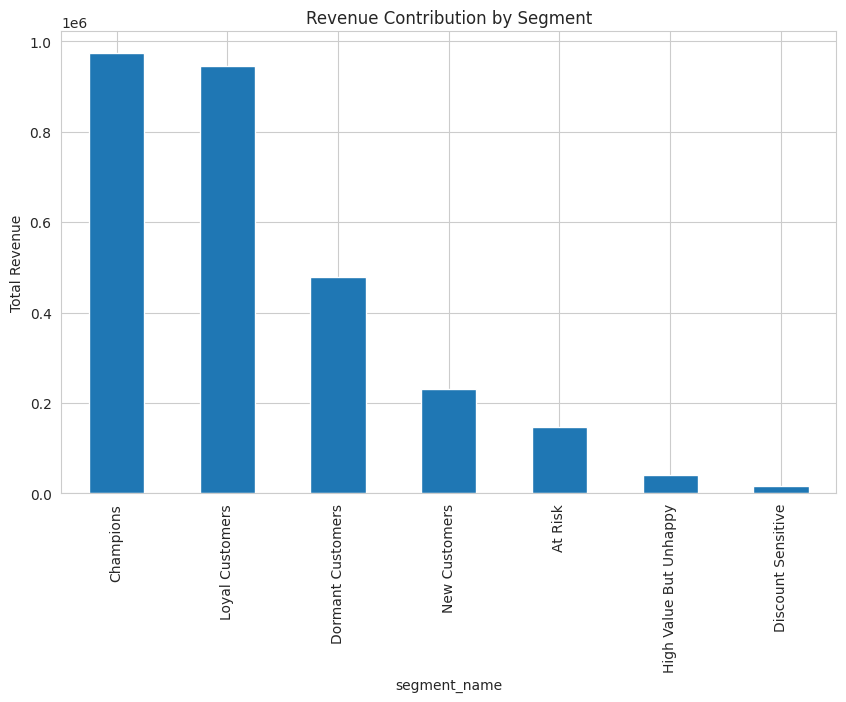

In [14]:
#Revenue Contribution
print('\nRevenue Contribution \n')
segment_revenue = (rfm.groupby('segment_name')['monetary_180d'].sum().sort_values(ascending=False))
print(segment_revenue)
#Visualization
segment_revenue.plot(kind='bar')
plt.title("Revenue Contribution by Segment")
plt.ylabel("Total Revenue")
plt.show()

## Segment Design

RFM variables identify customer value and engagement.

Additional behavioural signals were incorporated because:
- Support tickets indicate customer satisfaction.
- Return rate indicates purchase quality perception.
- Web sessions indicate digital engagement.
- Campaign clicks indicate marketing responsiveness.

Combining RFM with behavioural indicators produces more actionable retention segments than RFM alone.

In [15]:
#Export Final Segmentation Dataset
segments_output = rfm.copy()
segments_output = segments_output[['customer_id','segment_name','recency_days',
        'frequency_180d','monetary_180d','ticket_count_90d',
        'return_rate_180d','sessions_30d','campaign_clicks_30d','avg_discount_pct_180d']]
#export csv
segments_output.to_csv("segments.csv", index=False)
print("segments.csv exported successfully")
print("Rows:", len(segments_output))
segments_output.head()

segments.csv exported successfully
Rows: 2400


,customer_id,segment_name,recency_days,frequency_180d,monetary_180d,ticket_count_90d,return_rate_180d,sessions_30d,campaign_clicks_30d,avg_discount_pct_180d
0,CUST00001,Dormant Customers,107,1,362.73,0,0.0,1,0,0.23
1,CUST00002,Dormant Customers,40,1,581.00,1,0.0,8,0,0.23
2,CUST00003,Dormant Customers,171,1,649.98,0,0.0,1,0,0.47
3,CUST00004,Dormant Customers,131,1,1604.04,0,0.0,1,0,0.16
4,CUST00005,Champions,38,3,1781.90,0,0.0,18,1,0.48


### Key Findings

- Dormant Customers form the largest segment with 878 customers.
- Loyal Customers and Champions together represent a large portion of the customer base.
- New Customers account for 312 customers and present an opportunity for future growth.
- High Value But Unhappy and Discount Sensitive segments are smaller but require targeted retention strategies.
- Segment sizes help determine where retention efforts can have the greatest business impact.

In [16]:
# Top-value customers sorted by spend and inactivity for manual review and retention
rfm.sort_values(
    ['monetary_180d','recency_days'],
    ascending=[False,False])[[
    'customer_id','segment_name',
    'recency_days','frequency_180d',
    'monetary_180d','return_rate_180d',
    'ticket_count_90d','sessions_30d']].head(20)

,customer_id,segment_name,recency_days,frequency_180d,monetary_180d,return_rate_180d,ticket_count_90d,sessions_30d
1241,CUST01242,Champions,29,5,6982.41,0.000,1,0
314,CUST00315,Champions,17,6,6768.08,0.000,0,11
816,CUST00817,Champions,9,7,6352.75,0.000,0,13
229,CUST00230,Champions,37,6,6235.96,0.000,0,17
2316,CUST02317,Champions,1,6,5693.10,0.000,0,9
1151,CUST01152,Champions,1,6,5679.21,0.000,1,9
1282,CUST01283,Champions,40,8,5650.74,0.125,1,7
1029,CUST01030,Champions,32,5,5590.34,0.000,0,10
573,CUST00574,Champions,5,6,5505.69,0.000,0,14
1147,CUST01148,Loyal Customers,128,7,5448.00,0.000,0,1


In [17]:
#manual_review_cases
manual_review = rfm[
    ((rfm['monetary_180d'] > rfm['monetary_180d'].quantile(0.90)) &
        (rfm['recency_days'] > 90))
    |
    ((rfm['return_rate_180d'] > 0.20))
    |
    ((rfm['ticket_count_90d'] >= 1) &
    (rfm['monetary_180d'] > rfm['monetary_180d'].median()))
][['customer_id','segment_name','recency_days',
    'frequency_180d','monetary_180d','return_rate_180d','ticket_count_90d','sessions_30d']]
manual_review.head(15)

,customer_id,segment_name,recency_days,frequency_180d,monetary_180d,return_rate_180d,ticket_count_90d,sessions_30d
5,CUST00006,Loyal Customers,51,4,2989.58,0.250,2,2
20,CUST00021,Dormant Customers,77,2,1059.30,0.000,1,3
25,CUST00026,Loyal Customers,72,3,3561.39,0.333,1,14
26,CUST00027,High Value But Unhappy,70,1,2128.34,1.000,1,11
29,CUST00030,Champions,5,5,2819.98,0.000,2,11
32,CUST00033,Champions,12,3,1877.69,0.333,1,7
33,CUST00034,Dormant Customers,50,2,1460.21,0.000,1,7
35,CUST00036,Champions,27,4,1737.33,0.250,1,0
37,CUST00038,Loyal Customers,51,3,1955.61,0.000,1,5
41,CUST00042,Loyal Customers,87,5,4306.00,0.000,2,3
